<center>
<h1>Case study on predicting Salary Predictions
    </h1></center

<div >
    <h1>About Dataset</h1>
</div>

---
The Salary Data dataset contains 375 observations and 6 features, including employee details such as age, gender, education level, job title, years of experience, and salary. Among these, age, years of experience, and salary are numerical features, while gender, education level, and job title are categorical features.

 The aim of this project is to analyze how different employee characteristics influence salary levels. A multiple linear regression model is used to study the relationship between these features and predict employee salary based on their profile

**Find Dataset:https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer **


| Column                  | Meaning                               |
| ----------------------- | ------------------------------------- |
| **Age**                 | Employee age                          |
| **Gender**              | Male / Female                         |
| **Education Level**     | Degree level (Bachelor, Master, etc.) |
| **Job Title**           | Employee job role                     |
| **Years of Experience** | Work experience                       |
| **Salary**              | Employee salary                       |


**Goal:**

Build a Machine Learning Regression Model to predict employee salary based on experience, education, and job details.

_________________________________________________________________________________________________________________

# Importing modules for EDA

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Reading the dataset

In [45]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Understand about data

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [47]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [48]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [49]:
df = df.dropna()

In [50]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

# Understand Data Types

In [51]:
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

# Data Visualization


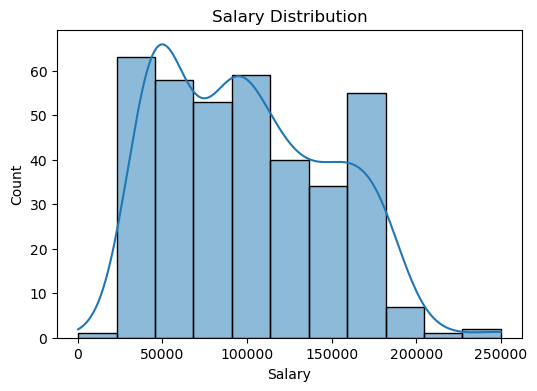

In [52]:
plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

Experience vs Salary

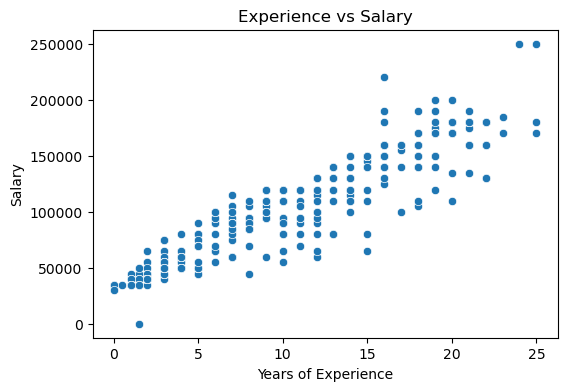

In [53]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Years of Experience'], y=df['Salary'])
plt.title("Experience vs Salary")
plt.show()

Age vs Salary

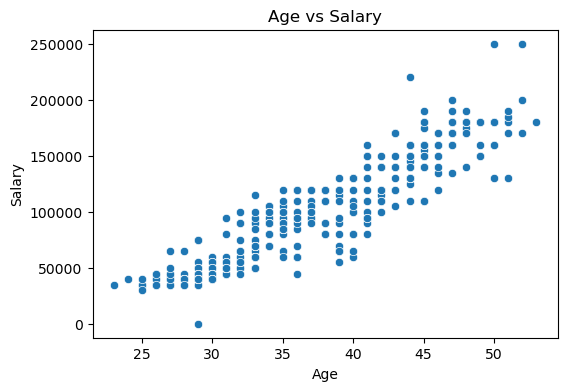

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Age'], y=df['Salary'])
plt.title("Age vs Salary")
plt.show()

Gender vs salary

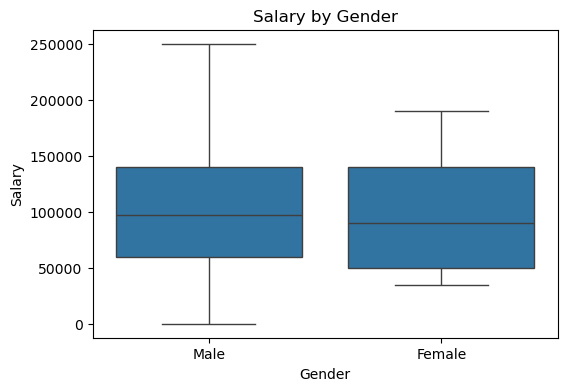

In [55]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Gender'], y=df['Salary'])
plt.title("Salary by Gender")
plt.show()

# Features and Target

In [56]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

# Define Categorical and Numerical Columns

In [57]:
cat_cols = ['Gender', 'Education Level', 'Job Title']
num_cols = ['Age', 'Years of Experience']

# One Hot Encoding

In [58]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = encoder.fit_transform(X[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

encoded_df = pd.DataFrame(encoded, columns=encoded_cols)

encoded_df.reset_index(drop=True, inplace=True)
X.reset_index(drop=True, inplace=True)

In [59]:
X_final = pd.concat([X[num_cols], encoded_df], axis=1)

print(X_final.shape)
print(y.shape)

(373, 181)
(373,)


# Combine Numerical + Encoded Columns

In [60]:
X_final = pd.concat([X[num_cols], encoded_df], axis=1)

X_final.head()

,Age,Years of Experience,Gender_Female,Gender_Male,Education Level_Bachelor's,Education Level_Master's,Education Level_PhD,Job Title_Account Manager,Job Title_Accountant,Job Title_Administrative Assistant,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,45.0,15.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36.0,7.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,52.0,20.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Train-Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)


# Feature Scaling

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Linear Regression Model

In [63]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
from sklearn.metrics import r2_score

y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression R2 Score: 0.8524450021260388


# Random Forest Model

In [65]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest R2 Score: 0.872475364070471


# Support Vector Regression (SVR)

In [67]:
from sklearn.svm import SVR

svr_model = SVR()

svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [68]:
y_pred_svr = svr_model.predict(X_test_scaled)

print("SVR R2 Score:", r2_score(y_test, y_pred_svr))


SVR R2 Score: -0.02312235807445817


In [69]:
scores = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Random Forest": r2_score(y_test, y_pred_rf),
    "SVR": r2_score(y_test, y_pred_svr)
}

print(scores)

{'Linear Regression': 0.8524450021260388, 'Random Forest': 0.872475364070471, 'SVR': -0.02312235807445817}


# Train Random Forest

In [70]:
from sklearn.ensemble import RandomForestRegressor

y_pred_rf = RandomForestRegressor()
y_pred_rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction

In [71]:
y_pred = y_pred_rf.predict(X_test_scaled)

# Accuracy

In [72]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8701858770687507


# Evaluate Model

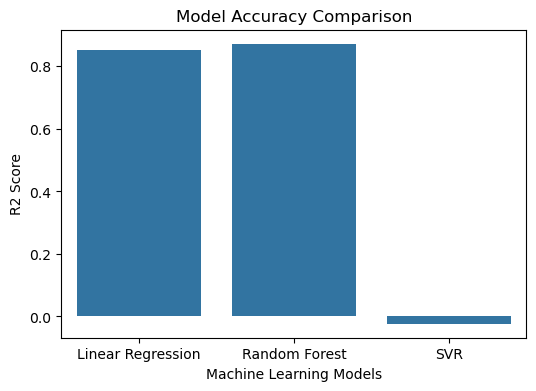

In [73]:
# Store R2 scores
scores = {
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "Random Forest": r2_score(y_test, rf_model.predict(X_test_scaled)),
    "SVR": r2_score(y_test, y_pred_svr)
}

# Convert to DataFrame
score_df = pd.DataFrame(list(scores.items()), columns=['Model', 'R2 Score'])

# Bar Chart
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='R2 Score', data=score_df)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("R2 Score")

plt.show()



In [74]:
import pickle

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
pickle.dump(rf_model.predict, open("LinearRegression.pkl", "wb"))

In [77]:
model = pickle.load(open("LinearRegression.pkl", "rb"))

# Save Model (Streamlit kosam)

In [78]:
import joblib
joblib.dump(rf_model, "random_forest_salary_model.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [79]:
prediction = model(X_test_scaled)
print(prediction)

[176150. 109750. 129900.  96750. 152700. 156200. 142500. 104250.  50100.
 100750. 131900. 142700.  40450.  99550. 129150.  50100.  55400.  42250.
  89300.  95400. 112850. 105150. 155000.  55700.  96750.  52100. 158150.
  40000. 111450. 150650.  46050. 119350.  47500. 149800. 108450.  37100.
 172400.  40000. 151600.  52300.  40000.  99750. 146450. 174150.  40000.
 159200. 112000.  42650.  40000.  40000. 158650.  91750. 129300. 101800.
 107200. 118250. 188600.  86450. 176150.  91400. 113900. 149800. 178950.
  55400.  49400.  40000.  47750. 108450.  40000.  35600.  90750. 105200.
  59900. 131750.  94500.]


In [80]:
import pandas as pd
results = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': prediction
})
results.head(10)

,Actual Salary,Predicted Salary
0,180000.0,176150.0
1,65000.0,109750.0
2,125000.0,129900.0
3,80000.0,96750.0
4,140000.0,152700.0
5,160000.0,156200.0
6,160000.0,142500.0
7,120000.0,104250.0
8,50000.0,50100.0
9,95000.0,100750.0


In [81]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, prediction)
print("Random Forest Regression R2 Score:", r2)

Random Forest Regression R2 Score: 0.872475364070471
